In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


In [3]:
DATA_PATH = "..\\Data\\01-01_철강_공정_개관_설비태그.csv"

PROCESS_KR = {
    "SNT": "소결",
    "CKO": "코크스로",
    "BF": "고로",
    "BOF": "전로",
    "CCM": "연주",
    "HSM": "열간압연",
    "CRM": "냉간압연",
    "UTL": "유틸리티",
}

MEASURE_KR = {
    "VIB": "진동",
    "CUR": "전류",
    "TMP": "온도",
    "PRS": "압력",
    "FLW": "유량",
    "SPD": "속도",
}

UPSTREAM = ["SNT", "CKO", "BF", "BOF"]
DOWNSTREAM = ["CCM", "HSM", "CRM"]
UTILITY = ["UTL"]


def classify_stage(proc):
    if proc in UPSTREAM:
        return "상공정"
    if proc in DOWNSTREAM:
        return "하공정"
    if proc in UTILITY:
        return "유틸리티"
    return "미등록"


In [4]:
# STEP 1. 파일 구조 확인
df = pd.read_csv(DATA_PATH, encoding="utf-8")

print("shape:", df.shape)
print("결측 개수:", df.isna().sum().sum())
print("컬럼:", df.columns.tolist())
print()
print(df.head())


shape: (24, 4)
결측 개수: 0
컬럼: ['tag', 'unit', 'sample_value', 'note']

                  tag  unit  sample_value             note
0  PL1-SNT-FAN-01-VIB  mm/s           2.8       소결 주배풍기 진동
1  PL1-SNT-FAN-01-CUR     A         412.5       소결 주배풍기 전류
2  PL1-SNT-CNV-02-SPD   m/s           1.6   소결광 이송 컨베이어 속도
3  PL1-CKO-PMP-01-PRS   bar           6.2  코크스로 냉각수 펌프 토출압
4  PL1-CKO-FUR-01-TMP  degC        1042.0      코크스로 연소실 온도


In [5]:
# STEP 2. tag 컬럼을 하이픈 기준으로 다섯 컬럼으로 분해
tag_parts = df["tag"].str.split("-", expand=True)
tag_parts.columns = ["plant", "proc", "equip", "unit_no", "meas"]

print("마디 개수 분포:", tag_parts.notna().sum(axis=1).value_counts().to_dict())

df = pd.concat([df, tag_parts], axis=1)
print()
print(df[["tag", "plant", "proc", "equip", "unit_no", "meas"]].head())


마디 개수 분포: {5: 24}

                  tag plant proc equip unit_no meas
0  PL1-SNT-FAN-01-VIB   PL1  SNT   FAN      01  VIB
1  PL1-SNT-FAN-01-CUR   PL1  SNT   FAN      01  CUR
2  PL1-SNT-CNV-02-SPD   PL1  SNT   CNV      02  SPD
3  PL1-CKO-PMP-01-PRS   PL1  CKO   PMP      01  PRS
4  PL1-CKO-FUR-01-TMP   PL1  CKO   FUR      01  TMP


In [6]:
# STEP 3. 공정명 매핑, stage 분류, 결과 표 작성
df["process_kr"] = df["proc"].map(PROCESS_KR).fillna("미등록")
df["measure_kr"] = df["meas"].map(MEASURE_KR).fillna("미등록")
df["stage"] = df["proc"].map(classify_stage)

print("미등록 공정 코드:", df.loc[df["process_kr"] == "미등록", "proc"].unique())
print("미등록 계측항목 코드:", df.loc[df["measure_kr"] == "미등록", "meas"].unique())
print("미등록 stage:", df.loc[df["stage"] == "미등록", "proc"].unique())
print()
print(pd.crosstab(df["stage"], df["proc"]))

result_columns = [
    "tag", "process_kr", "stage", "equip", "unit_no", "measure_kr", "unit", "sample_value", "note"
]
result_table = df[result_columns]
print()
print(result_table.to_string(index=False))


미등록 공정 코드: <StringArray>
[]
Length: 0, dtype: str
미등록 계측항목 코드: <StringArray>
[]
Length: 0, dtype: str
미등록 stage: <StringArray>
[]
Length: 0, dtype: str

proc   BF  BOF  CCM  CKO  CRM  HSM  SNT  UTL
stage                                       
상공정     4    2    0    2    0    0    3    0
유틸리티    0    0    0    0    0    0    0    3
하공정     0    0    3    0    3    4    0    0

               tag process_kr stage equip unit_no measure_kr    unit  sample_value              note
PL1-SNT-FAN-01-VIB         소결   상공정   FAN      01         진동    mm/s           2.8        소결 주배풍기 진동
PL1-SNT-FAN-01-CUR         소결   상공정   FAN      01         전류       A         412.5        소결 주배풍기 전류
PL1-SNT-CNV-02-SPD         소결   상공정   CNV      02         속도     m/s           1.6    소결광 이송 컨베이어 속도
PL1-CKO-PMP-01-PRS       코크스로   상공정   PMP      01         압력     bar           6.2   코크스로 냉각수 펌프 토출압
PL1-CKO-FUR-01-TMP       코크스로   상공정   FUR      01         온도    degC        1042.0       코크스로 연소실 온도
 PL1-BF-BLW-01-

[stage별 태그 개수]
stage  tag_count
  상공정         11
  하공정         10
 유틸리티          3

[공정별 태그 개수]
stage proc process_kr  tag_count
  상공정   BF         고로          4
  하공정  HSM       열간압연          4
  하공정  CCM         연주          3
  하공정  CRM       냉간압연          3
  상공정  SNT         소결          3
 유틸리티  UTL       유틸리티          3
  상공정  BOF         전로          2
  상공정  CKO       코크스로          2

태그가 가장 많은 공정
proc process_kr stage  tag_count
  BF         고로   상공정          4
 HSM       열간압연   하공정          4


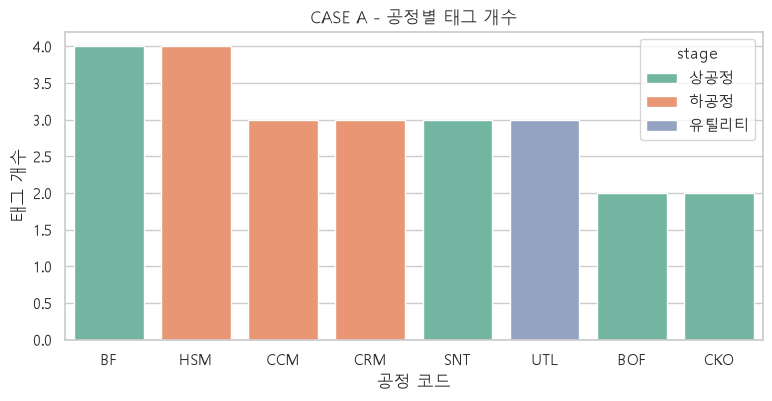

In [7]:
# CASE A. 공정별로 묶어 태그가 가장 많은 공정 확인
stage_count = (
    df["stage"]
    .value_counts()
    .reindex(["상공정", "하공정", "유틸리티"], fill_value=0)
    .rename_axis("stage")
    .reset_index(name="tag_count")
)
print("[stage별 태그 개수]")
print(stage_count.to_string(index=False))

process_count = (
    df.groupby(["stage", "proc", "process_kr"])
    .size()
    .reset_index(name="tag_count")
    .sort_values(["tag_count", "proc"], ascending=[False, True])
)
print("\n[공정별 태그 개수]")
print(process_count.to_string(index=False))

max_process_count = process_count["tag_count"].max()
most_common_process = process_count.loc[process_count["tag_count"] == max_process_count]
print("\n태그가 가장 많은 공정")
print(most_common_process[["proc", "process_kr", "stage", "tag_count"]].to_string(index=False))

plt.figure(figsize=(9, 4))
sns.barplot(data=process_count, x="proc", y="tag_count", hue="stage", palette="Set2")
plt.title("CASE A - 공정별 태그 개수")
plt.xlabel("공정 코드")
plt.ylabel("태그 개수")
plt.show()


[계측 항목별 태그 개수]
meas measure_kr  tag_count         units
 TMP         온도          6          degC
 CUR         전류          5             A
 PRS         압력          5      bar, kPa
 VIB         진동          4          mm/s
 FLW         유량          3 Nm3/min, m3/h
 SPD         속도          1           m/s

태그가 가장 많은 계측 항목
meas measure_kr  tag_count units
 TMP         온도          6  degC


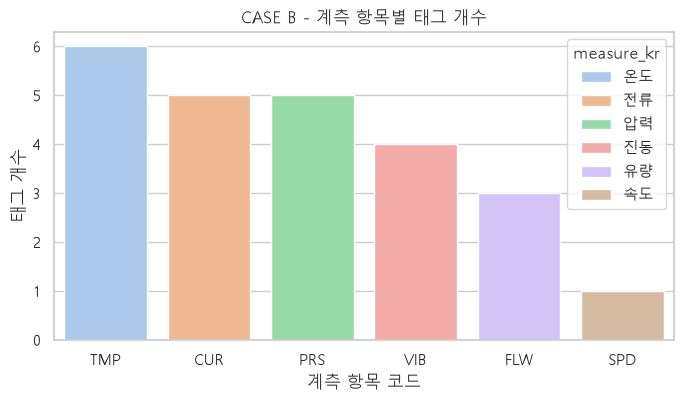

In [8]:
# CASE B. 계측 항목별로 묶어 가장 많은 물리량 확인
measure_count = (
    df.groupby(["meas", "measure_kr"])
    .agg(tag_count=("tag", "size"), units=("unit", lambda x: ", ".join(sorted(x.unique()))))
    .reset_index()
    .sort_values(["tag_count", "meas"], ascending=[False, True])
)
print("[계측 항목별 태그 개수]")
print(measure_count.to_string(index=False))

max_measure_count = measure_count["tag_count"].max()
most_common_measure = measure_count.loc[measure_count["tag_count"] == max_measure_count]
print("\n태그가 가장 많은 계측 항목")
print(most_common_measure[["meas", "measure_kr", "tag_count", "units"]].to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=measure_count, x="meas", y="tag_count", hue="measure_kr", palette="pastel")
plt.title("CASE B - 계측 항목별 태그 개수")
plt.xlabel("계측 항목 코드")
plt.ylabel("태그 개수")
plt.show()


In [9]:
# 결과 공유용 요약
summary = pd.DataFrame({
    "항목": [
        "태그 구조",
        "stage별 개수",
        "태그 최다 공정",
        "태그 최다 계측항목",
        "UTL 분류",
    ],
    "결과": [
        "24개 모두 다섯 마디 구조",
        "상공정 11개, 하공정 10개, 유틸리티 3개",
        "BF(고로) 4개, HSM(열간압연) 4개",
        "TMP(온도) 6개",
        "상공정/하공정이 아닌 유틸리티로 별도 분류",
    ],
})
summary


,항목,결과
0,태그 구조,24개 모두 다섯 마디 구조
1,stage별 개수,"상공정 11개, 하공정 10개, 유틸리티 3개"
2,태그 최다 공정,"BF(고로) 4개, HSM(열간압연) 4개"
3,태그 최다 계측항목,TMP(온도) 6개
4,UTL 분류,상공정/하공정이 아닌 유틸리티로 별도 분류
